## Homogeneous BRDF

Estimation using Metropolis-Hastings without gradient

(grayscale / microfacet)

Experiment #2: highlight not visible

In [1]:
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image

In [2]:
import torch
from tqdm import tqdm
import time

In [3]:
scene = Scene()
diffuse = 0.3
specular = 0.3
roughness = 0.3
black = (0,0,0)
scene.set('mat', MicrofacetBRDF(diffuse, specular, roughness))
scene.set('black', DiffuseBRDF(black))
scene.set('mesh1', Mesh.from_file("quad.obj", 'mat')) # surface to reconstruct
scene.set('mesh2', Mesh.from_file("light.obj", 'black', radiance=400)) # area light source
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('path', {'max_depth': 3, 'hide_emitters': True}))
scene.set('cam1', PerspectiveCamera.from_lookat(fov=26, origin=(5,1.8,0), target=(0,0,0), up=(0,1,0))) # camera

In [4]:
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 1,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't allow changing spp, workaround here to render a 128-spp target image
# I_t = renderer(scene)
I_t = torch.cat([renderer(scene) for _ in range(128)]).mean(axis=0).unsqueeze(dim=0)

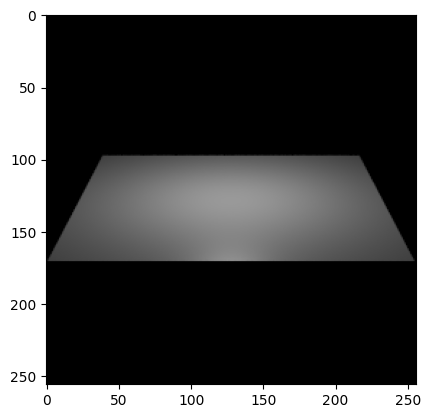

In [5]:
# Visualize the target Image
from matplotlib import pyplot as plt
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
def showhist(a):
    plt.hist(a.view(-1).detach().cpu().numpy(), bins=100)
showimg(I_t)

### Loss Function (Likelihood)

Because we're reconstructing the texture for an exact match, we can simply use per-pixel loss in the image space.

In [6]:
def logpdf(img):
    from math import sqrt, pi
    sigma = torch.tensor(0.02)
    # log of density of a normal distribution
    lpdf = ((img - I_t).pow(2.0)/(2.0*sigma.pow(2.0)) + \
                (sqrt(2*pi)*sigma).log()).mean()
    return lpdf### Posterior Distribution

### Posterior Distribution

In [7]:
# To avoid clipping, we are mapping parameters from a finite range (0,1) to (-inf,inf)
def orig_to_norm(x):
    return torch.log(x/(1-x))

def norm_to_orig(y):
    return torch.sigmoid(y)

In [8]:
# potential energy in the parametric space
def U(x):
    scene['mat']['d'] = norm_to_orig(x[0])
    scene['mat']['s'] = norm_to_orig(x[1])
    scene['mat']['r'] = norm_to_orig(x[2])
    img = renderer(scene)
    lpdf = logpdf(img)
    return lpdf, img

### Visualize Posterior Distribution

In [13]:
# generate a uniform grid on a slice of the original parametric space (blue=0.2)
# to visualize the posterior distribution
first_components = []
second_components = []
U0 = []
U1 = []
U2 = []
res = 50
for i in tqdm(range(res)):
    for j in range(res):
        x = i/res + 0.5/res
        y = j/res + 0.5/res
        first_components.append(x)
        second_components.append(y)
        U0.append(U(orig_to_norm(torch.tensor([x,y,0.3]).cuda()))[0])
        U1.append(U(orig_to_norm(torch.tensor([x,0.3,y]).cuda()))[0])
        U2.append(U(orig_to_norm(torch.tensor([0.3,x,y]).cuda()))[0])

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [02:08<00:00,  2.57s/it]


Text(0.5, 0.98, 'Posterior distribution (roughness set to GT=0.3)')

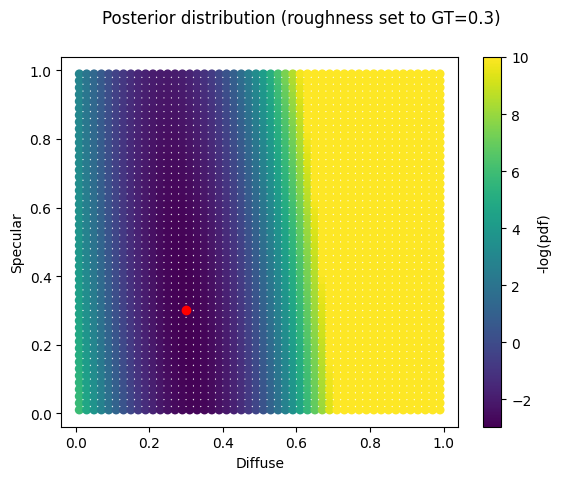

In [32]:
plt.scatter(first_components, second_components, c=[u.cpu() for u in U0], s=30, vmax=10)
cbar = plt.colorbar()
cbar.set_label('-log(pdf)')
plt.xlabel("Diffuse")
plt.ylabel('Specular')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (roughness set to GT=0.3)')

Text(0.5, 0.98, 'Posterior distribution (specular set to GT=0.3)')

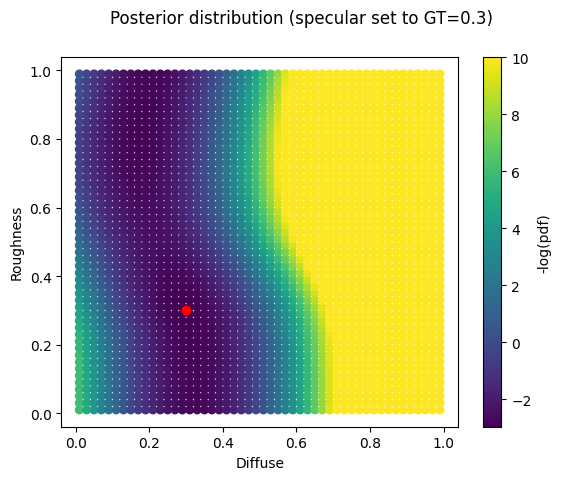

In [33]:
plt.scatter(first_components, second_components, c=[u.cpu() for u in U1], s=30, vmax=10)
cbar = plt.colorbar()
cbar.set_label('-log(pdf)')
plt.xlabel("Diffuse")
plt.ylabel('Roughness')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (specular set to GT=0.3)')

Text(0.5, 0.98, 'Posterior distribution (diffuse set to GT=0.3)')

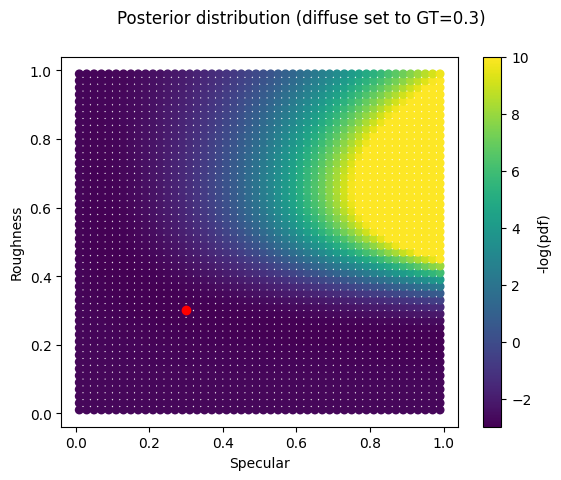

In [34]:
plt.scatter(first_components, second_components, c=[u.cpu() for u in U2], s=30, vmax=10)
cbar = plt.colorbar()
cbar.set_label('-log(pdf)')
plt.xlabel("Specular")
plt.ylabel('Roughness')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (diffuse set to GT=0.3)')

tensor(-2.9693, device='cuda:0')


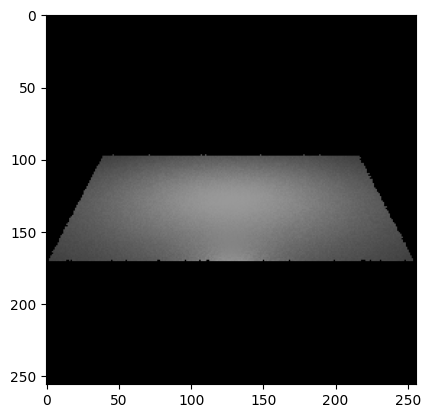

In [31]:
lpdf, img = U(orig_to_norm(torch.tensor([0.3, 0.3, 0.3]).cuda()))
print(lpdf)
showimg(img)

In [36]:
import math

Text(0.5, 0.98, 'Posterior distribution (roughness set to GT=0.3)')

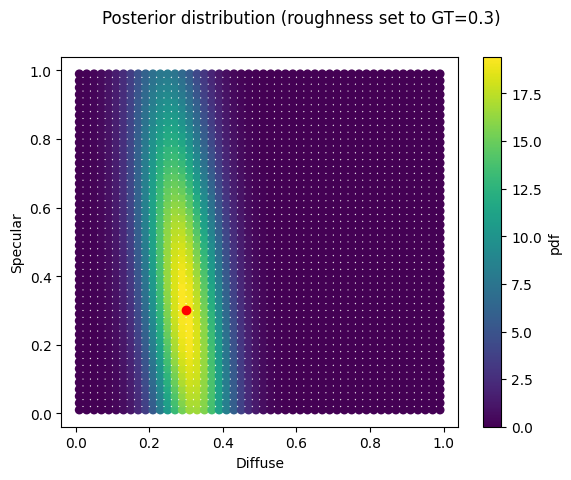

In [38]:
plt.scatter(first_components, second_components, c=[math.exp(-u.cpu()) for u in U0], s=30)
cbar = plt.colorbar()
cbar.set_label('pdf')
plt.xlabel("Diffuse")
plt.ylabel('Specular')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (roughness set to GT=0.3)')

Text(0.5, 0.98, 'Posterior distribution (specular set to GT=0.3)')

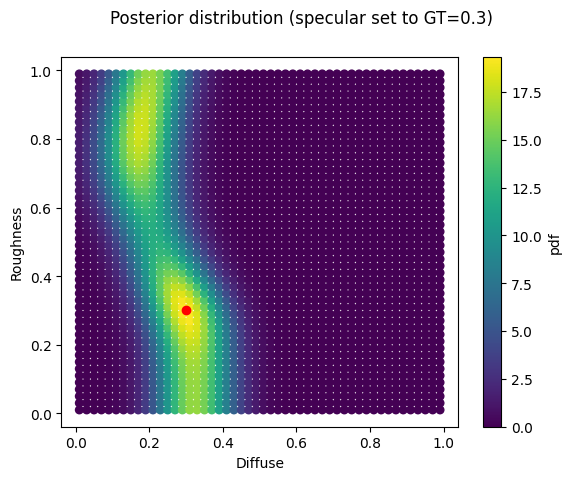

In [41]:
plt.scatter(first_components, second_components, c=[math.exp(-u.cpu()) for u in U1], s=30)
cbar = plt.colorbar()
cbar.set_label('pdf')
plt.xlabel("Diffuse")
plt.ylabel('Roughness')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (specular set to GT=0.3)')

Text(0.5, 0.98, 'Posterior distribution (diffuse set to GT=0.3)')

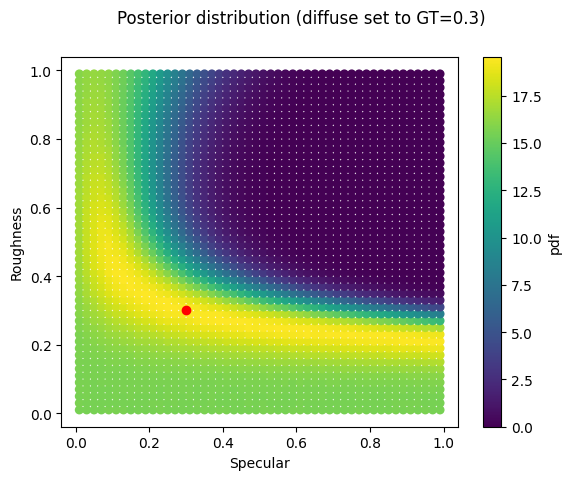

In [42]:
plt.scatter(first_components, second_components, c=[math.exp(-u.cpu()) for u in U2], s=30)
cbar = plt.colorbar()
cbar.set_label('pdf')
plt.xlabel("Specular")
plt.ylabel('Roughness')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (diffuse set to GT=0.3)')

### Parameter Mapping & Prior Distribution

To make sure parameters are in proper range and avoid dealing with clipping samples, we map parameters from a finite range into the entire real number range. Specifically in this experiment, the *original parameters* are all in range (0,1) denoted as x. We map them into (-inf,inf) using the formula y=logit(x). Invert it, we have x=sigmoid(y). We call y *normalized parameter*.

We're assuming uniform prior distribution in the parametric space x~U[0,1]. After the inverse sigmoid mapping, the prior distribution in (-inf,inf) should be pdf(y) = x*(1-x) = sigmoid(y) * (1-sigmoid(y)).

Note that for numerical stability and convenience for sampling, all pdfs are represented as -log(pdf).

In [9]:
# To avoid clipping, we are mapping parameters from a finite range (0,1) to (-inf,inf)
def orig_to_norm(x):
    return torch.log(x/(1-x))

def norm_to_orig(y):
    return torch.sigmoid(y)

In [10]:
def logpdf_prior(x): # here x is normalized parameter (tensor)
    xo = norm_to_orig(x)
    return -(xo * (1-xo)).log().sum(axis=-1) # multiplied over all channels

### Loss Function (Likelihood)

Because we're reconstructing the texture for an exact match, we can simply use per-pixel loss in the image space.

In [11]:
def logpdf(img):
    from math import sqrt, pi
    sigma = torch.tensor(0.02)
    # log of density of a normal distribution
    lpdf = ((img - I_t).pow(2.0)/(2.0*sigma.pow(2.0)) + \
                (sqrt(2*pi)*sigma).log()).mean()
    return lpdf

### Posterior Probability

In [12]:
def U_orig(xo):
    scene['mat']['d'] = xo[0]
    scene['mat']['s'] = xo[1]
    scene['mat']['r'] = xo[2]
    img = renderer(scene)
    lpdf = logpdf(img)
    return lpdf, img

# potential energy in the normalized parametric space
def U(x):
    scene['mat']['d'] = norm_to_orig(x[0])
    scene['mat']['s'] = norm_to_orig(x[1])
    scene['mat']['r'] = norm_to_orig(x[2])
    img = renderer(scene)
    lpdf = logpdf(img) + logpdf_prior(x)
    return lpdf, img

### Metropolis-Hastings

In [13]:
from tqdm import tqdm
import time
from torch.distributions import Normal

In [41]:
class MH:
    def __init__(self, sigma=1):
        self.num_accepts = 0
        self.num_rejects = 0
        self.xs = []
        self.Us = []
        self.sigma = sigma # step size
    
    def proposal(self, x0, U0):
        distr = Normal(x0, self.sigma)
        x_tmp = distr.sample()
        U_tmp, _ = U(x_tmp)
        arej = torch.exp((U0-U_tmp).clamp(max=88))
        return arej, x_tmp, U_tmp

    def sample(self, x0, nsamples=1000):
        U0, _ = U(x0)
        for i in tqdm(range(nsamples)):
            # generate proposal sample
            arej, x_tmp, U_tmp = self.proposal(x0, U0)
            # accept or reject proposal on a per-pixel basis
            accepts = torch.bernoulli(arej.clamp_max(1)).bool()
            self.num_accepts += accepts
            if accepts:
                x0 = x_tmp
                U0 = U_tmp
#             x0 = torch.where(accepts.unsqueeze(-1), x_tmp, x0).detach()
            self.xs.append(x0)
            self.Us.append(U0)

In [42]:
mcmc1 = MH(1.0)
mcmc2 = MH(0.2)
mcmc3 = MH(3)

x0 = orig_to_norm(torch.zeros((3)).cuda().uniform_(0, 1))
mcmc1.sample(x0, nsamples=40000)

100%|████████████████████████████████████████████████████████████████████████████| 40000/40000 [11:53<00:00, 56.10it/s]


In [43]:
mcmc2.sample(x0, nsamples=40000)
mcmc3.sample(x0, nsamples=40000)

  0%|▎                                                                             | 166/40000 [00:02<11:48, 56.21it/s]


KeyboardInterrupt: 

In [54]:
mcmc3.sample(x0, nsamples=40000)

100%|████████████████████████████████████████████████████████████████████████████| 40000/40000 [11:49<00:00, 56.41it/s]


In [55]:
mcmc1.num_accepts, mcmc2.num_accepts, mcmc3.num_accepts

(tensor(12920, device='cuda:0'),
 tensor(32191, device='cuda:0'),
 tensor(2883, device='cuda:0'))

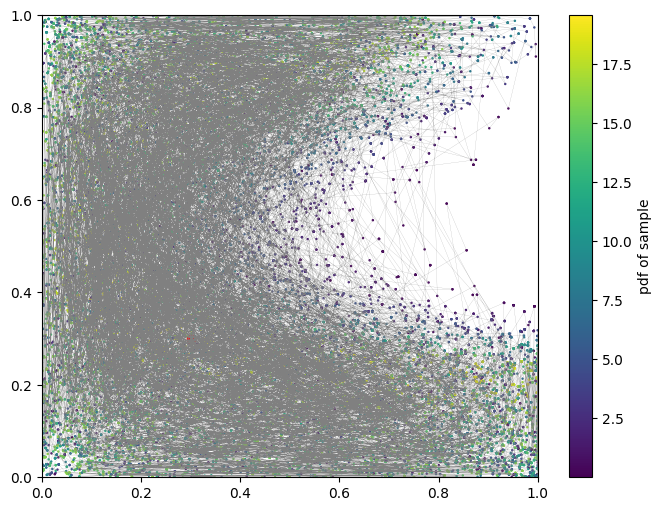

In [46]:
mcmc = mcmc1
# Visualize these samples in original parametric space
axes = [1, 2]
xs = []
ys = []
zs = []
for i,p in enumerate(mcmc.xs):
    po = norm_to_orig(p)
    xs.append(po.cpu()[axes[0]])
    ys.append(po.cpu()[axes[1]])
    u = mcmc.Us[i] - (-(po * (1-po)).log().sum(axis=-1))
    zs.append((-u).exp().cpu())

plt.figure(figsize=(8, 6))
plt.scatter(xs, ys, c=zs, s=0.6)
plt.plot(xs, ys, color='gray', linewidth=0.1)
# plt.scatter(xs, ys, c=zs, s=0.2)
plt.xlim(0, 1)
plt.ylim(0, 1)
cbar = plt.colorbar()
cbar.set_label('pdf of sample')


# visualize the ground truth
# gt = orig_to_norm(torch.tensor(diffuse_gt))
plt.scatter(0.3, 0.3, color='red')


# overlay contour of posterior distribution in a cross section (which isn't equivalent to marginal distribution)


### Performance Measurement

- Autocorrelation
- Convergence diagnostics
- Burn-in period
- Stationarity
- Trace plots & density plots

(0.0, 1000.0)

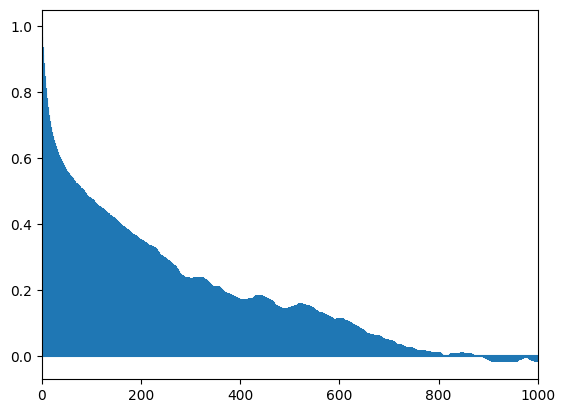

In [52]:
import numpy
from scipy import signal
xs = numpy.stack([norm_to_orig(p).cpu().numpy() for p in mcmc2.xs])
maxlag = 1000
plt.acorr(xs[:,0], maxlags=maxlag, detrend=lambda x:signal.detrend(x, type='constant'))
plt.xlim([0, maxlag])

(0.0, 1000.0)

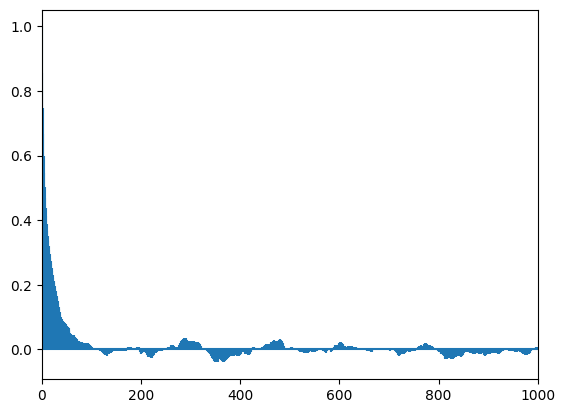

In [53]:
import numpy
from scipy import signal
xs = numpy.stack([norm_to_orig(p).cpu().numpy() for p in mcmc1.xs])
maxlag = 1000
plt.acorr(xs[:,0], maxlags=maxlag, detrend=lambda x:signal.detrend(x, type='constant'))
plt.xlim([0, maxlag])

(0.0, 1000.0)

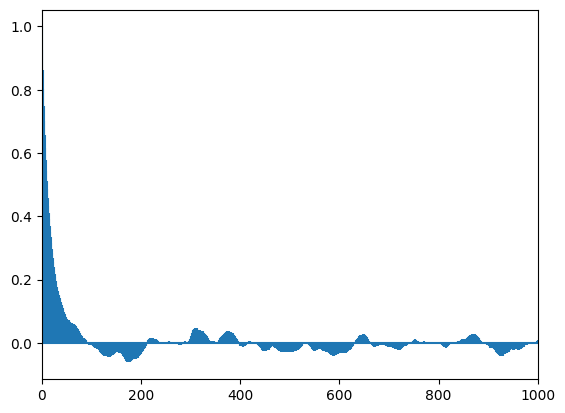

In [56]:
import numpy
from scipy import signal
xs = numpy.stack([norm_to_orig(p).cpu().numpy() for p in mcmc3.xs])
maxlag = 1000
plt.acorr(xs[:,0], maxlags=maxlag, detrend=lambda x:signal.detrend(x, type='constant'))
plt.xlim([0, maxlag])

In [58]:
len(mcmc3.xs)

40166